# CREATE FIGURE 3F AND SUPPLEMENTARY FIGURE 12A
## last updated: 06.12.26

In [1]:
%run 'ecDNAInspector_functions.ipynb'

/Users/spribus/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
import numpy as np
import pandas as pd
import os
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [3]:
os.chdir('/Users/spribus/ecDNAInspector_Usage_Notebooks')

In [4]:
cycle_level_data_path = 'full_tool_testing/CCLE_intrasample_filt_cycle_data_w_conf.csv'
cohort_df = pd.read_csv(cycle_level_data_path)

In [5]:
cohort_df["Tissue"] = cohort_df["Sample"].str.split("_", n=1).str[1]

In [6]:
full_cohort_group_df = cohort_df

In [7]:
HC_cohort_group_df = full_cohort_group_df[full_cohort_group_df["Confidence"] == "high"]
MC_cohort_group_df = full_cohort_group_df[full_cohort_group_df["Confidence"] == "medium"]
LC_cohort_group_df = full_cohort_group_df[full_cohort_group_df["Confidence"] == "low"]

In [8]:
tissue_list = full_cohort_group_df["Tissue"].value_counts().index.tolist()

In [9]:
breast_full_df = full_cohort_group_df[full_cohort_group_df["Tissue"] == "BREAST"]

breast_cell_lines = (
    breast_full_df["Sample"]
    .value_counts()
    .index
    .tolist()
)

In [10]:
lung_full_df = full_cohort_group_df[full_cohort_group_df["Tissue"] == "LUNG"]

lung_cell_lines = (
    lung_full_df["Sample"]
    .value_counts()
    .index
    .tolist()
)

In [11]:
ccle_cytocelldb = pd.read_csv("full_tool_testing/CytoCellDB_Supp_File1.csv")

In [12]:
ccle_cytocelldb = ccle_cytocelldb[["CCLE_Name_Format", "ECDNA", "HSR", "Validation source", "AA prediction"]]

In [13]:
ccle_cytocelldb = ccle_cytocelldb.dropna(subset=["ECDNA"])

In [14]:
ccle_cytocelldb = ccle_cytocelldb.rename(columns={
    "ECDNA": "cytocelldb ecDNA pred",
    "AA prediction": "AA ecDNA pred"
})

In [15]:
cytocell_merged = pd.merge(full_cohort_group_df, ccle_cytocelldb, left_on="Sample", right_on="CCLE_Name_Format")

In [16]:
cytocell_merged = cytocell_merged[cytocell_merged["cytocelldb ecDNA pred"] != "P"]

In [17]:
cytocell_merged_lung = cytocell_merged[cytocell_merged["Tissue"] == "LUNG"]
cytocell_merged_breast = cytocell_merged[cytocell_merged["Tissue"] == "BREAST"]

### Figure 3F

In [18]:
# Binary indicator for high confidence cycles
cytocell_merged_breast["high_conf"] = (cytocell_merged_breast["Confidence"] == "high").astype(int)

sample_df = (
    cytocell_merged_breast.groupby("Sample")
      .agg(
          prop_high_conf=("high_conf", "mean"),
          n_cycles=("high_conf", "size"),
          cytocelldb_pred=("cytocelldb ecDNA pred", "first")
      )
      .reset_index()
)

sample_df["label"] = (
    sample_df["cytocelldb_pred"]
    .map({"Y": 1, "N": 0})
)

sample_df = sample_df[sample_df["n_cycles"] >= 5]

/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_3749/1630497101.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cytocell_merged_breast["high_conf"] = (cytocell_merged_breast["Confidence"] == "high").astype(int)


In [22]:
len(sample_df)

8

In [19]:
fpr, tpr, thresholds = roc_curve(
    sample_df["label"],
    sample_df["prop_high_conf"]
)

roc_auc = auc(fpr, tpr)

print(f"AUC = {roc_auc:.3f}")

AUC = 0.875


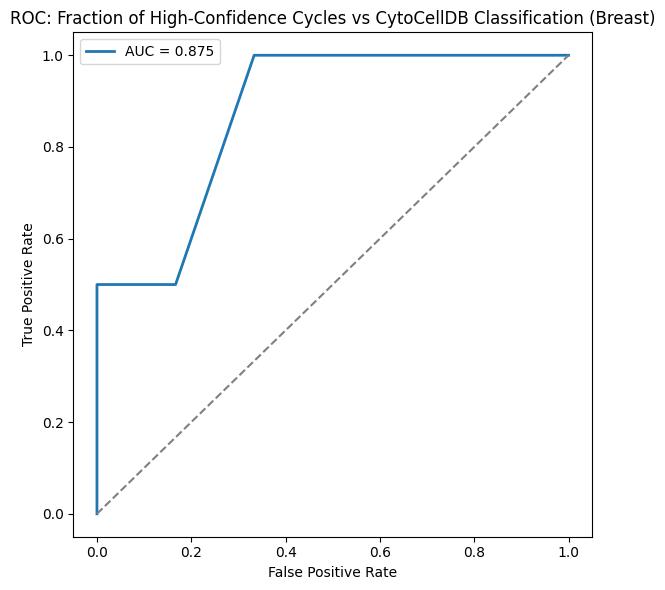

In [20]:
plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    lw=2,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot([0,1], [0,1], "--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC: Fraction of High-Confidence Cycles vs CytoCellDB Classification (Breast)")
plt.legend()

plt.tight_layout()
plt.show()

In [23]:
# Binary indicator for high confidence cycles
cytocell_merged["high_conf"] = (cytocell_merged["Confidence"] == "high").astype(int)

sample_df = (
    cytocell_merged.groupby("Sample")
      .agg(
          prop_high_conf=("high_conf", "mean"),
          n_cycles=("high_conf", "size"),
          cytocelldb_pred=("cytocelldb ecDNA pred", "first")
      )
      .reset_index()
)

sample_df["label"] = (
    sample_df["cytocelldb_pred"]
    .map({"Y": 1, "N": 0})
)

sample_df = sample_df[sample_df["n_cycles"] >= 5]

In [24]:
len(sample_df)

50

In [25]:
fpr, tpr, thresholds = roc_curve(
    sample_df["label"],
    sample_df["prop_high_conf"]
)

roc_auc = auc(fpr, tpr)

print(f"AUC = {roc_auc:.3f}")

AUC = 0.786


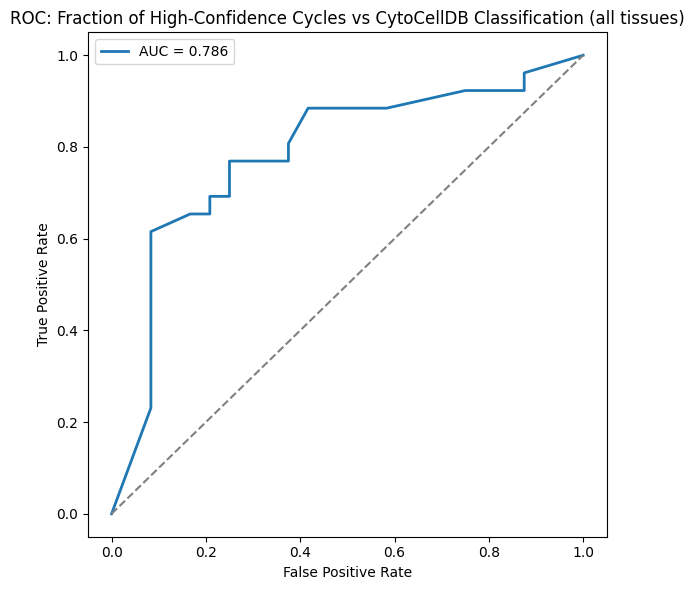

In [26]:
plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    lw=2,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot([0,1], [0,1], "--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC: Fraction of High-Confidence Cycles vs CytoCellDB Classification (all tissues)")
plt.legend()

plt.tight_layout()
plt.show()

In [27]:
# Binary indicator for high confidence cycles
cytocell_merged_lung["high_conf"] = (cytocell_merged_lung["Confidence"] == "high").astype(int)

sample_df = (
    cytocell_merged_lung.groupby("Sample")
      .agg(
          prop_high_conf=("high_conf", "mean"),
          n_cycles=("high_conf", "size"),
          cytocelldb_pred=("cytocelldb ecDNA pred", "first")
      )
      .reset_index()
)

sample_df["label"] = (
    sample_df["cytocelldb_pred"]
    .map({"Y": 1, "N": 0})
)

sample_df = sample_df[sample_df["n_cycles"] >= 5]

/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_3749/1475707642.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cytocell_merged_lung["high_conf"] = (cytocell_merged_lung["Confidence"] == "high").astype(int)


In [28]:
len(sample_df)

26

In [41]:
fpr, tpr, thresholds = roc_curve(
    sample_df["label"],
    sample_df["prop_high_conf"]
)

roc_auc = auc(fpr, tpr)

print(f"AUC = {roc_auc:.3f}")

AUC = 0.830


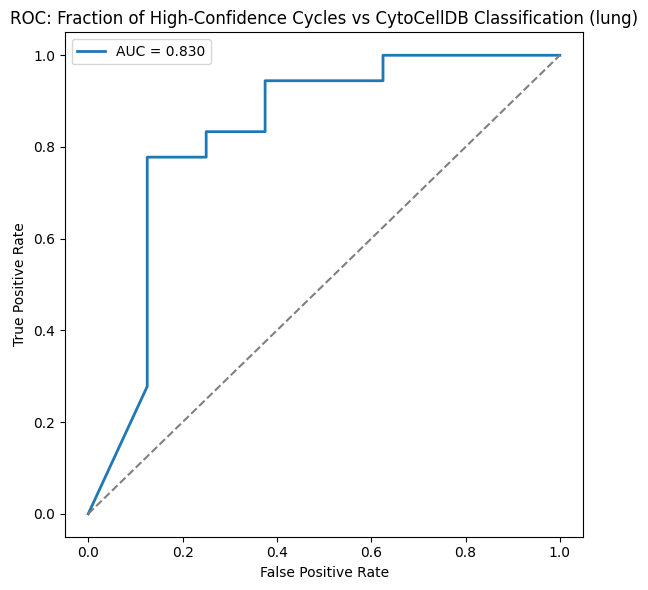

In [42]:
plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    lw=2,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot([0,1], [0,1], "--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC: Fraction of High-Confidence Cycles vs CytoCellDB Classification (lung)")
plt.legend()

plt.tight_layout()
plt.show()

### Supplementary figure 9A

In [45]:
cytocell_sample_order = (
    cytocell_merged[["Sample", "cytocelldb ecDNA pred"]]
    .drop_duplicates()
    .sort_values(
        by="cytocelldb ecDNA pred",
        ascending=False  # "Y" > "N"
    )["Sample"]
    .tolist()
)

In [46]:
x = 5

cytocell_merged_filt = cytocell_merged.groupby("Sample").filter(lambda g: len(g) >= x)

cytocell_sample_order_filt = (
    cytocell_merged_filt[["Sample", "cytocelldb ecDNA pred"]]
    .drop_duplicates()
    .sort_values(
        by="cytocelldb ecDNA pred",
        ascending=False  # "Y" > "N"
    )["Sample"]
    .tolist()
)

/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_3509/474299837.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_sizes = group_analysis_df.groupby(group).size()
/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_3509/474299837.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  proportions = group_analysis_df.groupby(group)[metric].value_counts(normalize=True).unstack(fill_value=0)


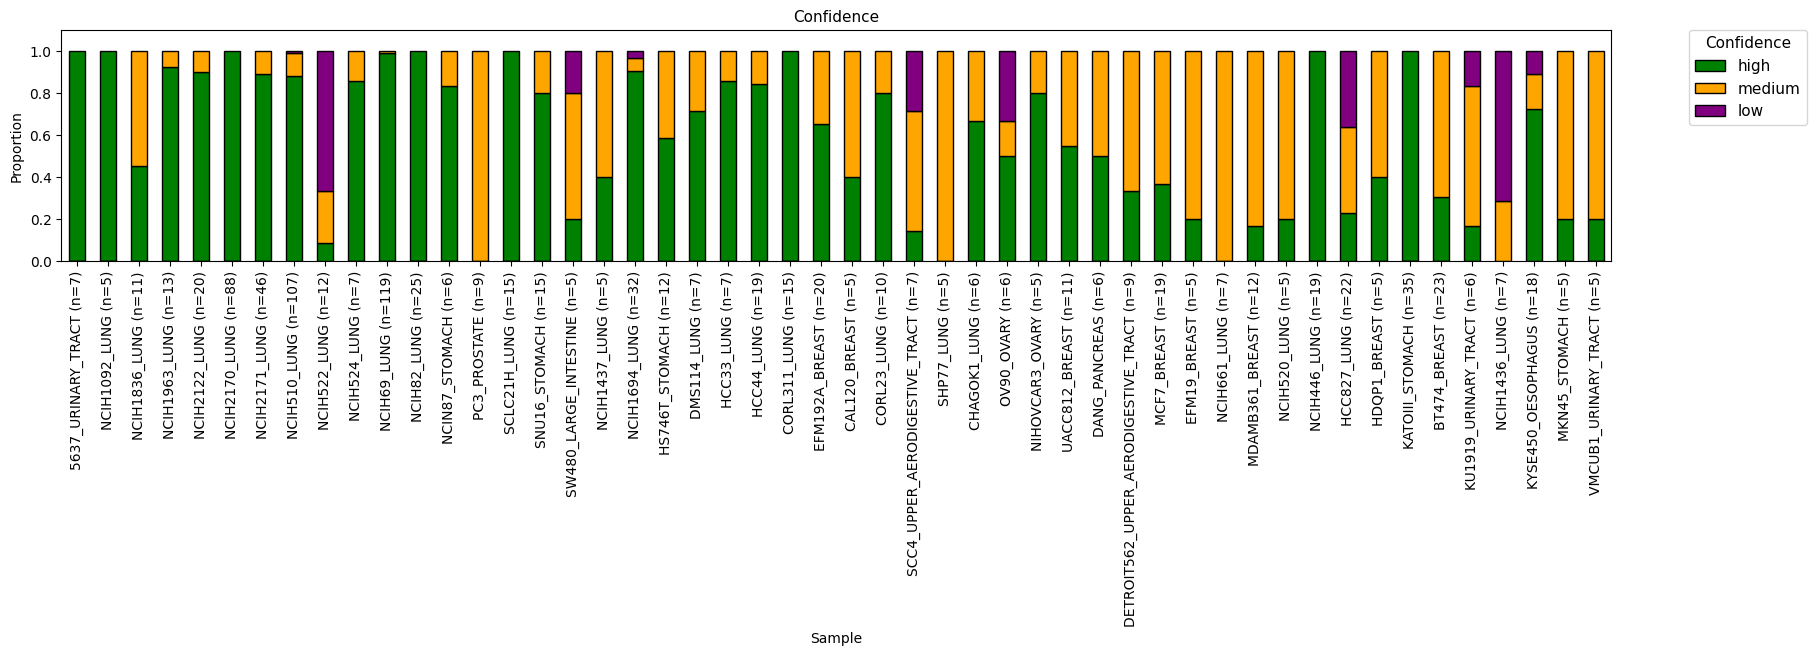

Chi-squared Test of Independence:
  Chi² = 768.5699, df = 98, p = 1.3626e-104
  Cramér's V = 0.6571


In [47]:
# replace with your preferred subset or the full cohort_df
data_df = cytocell_merged_filt

# select a categorical metric from the cohort_df 
metric = "Confidence"

# replace with the name of the column you would like to group by
group = 'Sample'

# replace with the x-axis ordering of groups you prefer
group_order = cytocell_sample_order_filt
data_df[group] = pd.Categorical(data_df[group], categories=group_order, ordered=True)

# choose colors for metrics: adjust count and value of metrics according to values for metric in full_cohort_group_df
metric_colors = {"high": 'green', "medium": 'orange', "low": 'purple'}

# choose order for metrics: adjust count and value of metrics according to values for metric in full_cohort_group_df
metric_order = ["high", "medium", "low"]

plot_prop_metric_by_group_barplot(data_df, group, metric, fig_size=(20, 3), rot=90, colors = metric_colors, metric_order=metric_order)